# PANAGEA exploration 1 — Coverage in space, time and variables

Using the `ocpy.insitu.panagea` API, this notebook surveys **what the
PANAGEA V3 compilation actually contains**: how many observations each of
the seven datasets holds, where they were collected, when, and how the
measurement types overlap.

Findings are summarised at the bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ocpy.insitu import panagea

## Observation counts per dataset

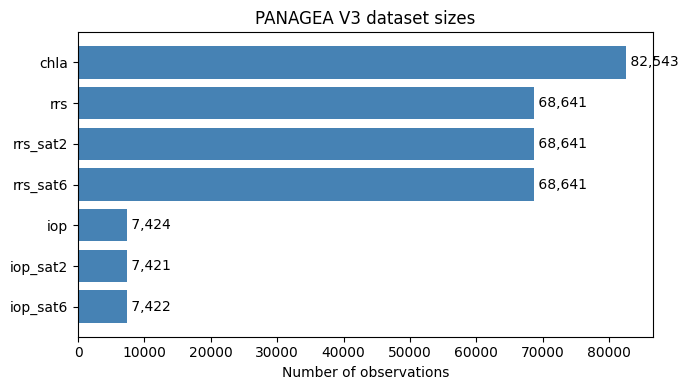

{'chla': 82543,
 'rrs': 68641,
 'rrs_sat2': 68641,
 'rrs_sat6': 68641,
 'iop': 7424,
 'iop_sat2': 7421,
 'iop_sat6': 7422}

In [2]:
counts = {}
frames = {}
for key in panagea.file_catalog():
    df = panagea.load(key)
    frames[key] = df
    counts[key] = len(df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(list(counts), list(counts.values()), color='steelblue')
ax.set_xlabel('Number of observations')
ax.set_title('PANAGEA V3 dataset sizes')
for i, v in enumerate(counts.values()):
    ax.text(v, i, f' {v:,}', va='center')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
counts

Rrs dominates (~68.6k); chlorophyll is the largest single-variable table
(~82.5k); the IOP tables are an order of magnitude smaller (~7.4k).

## Global spatial coverage

Plot chlorophyll station locations, coloured by log10(chl).

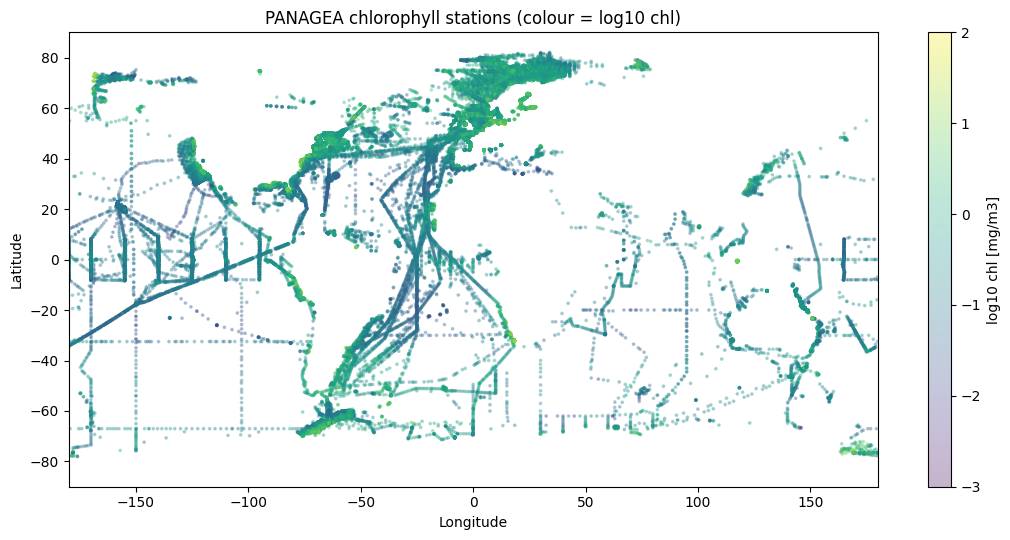

In [3]:
chla = frames['chla']
chl = chla['chla_hplc'].fillna(chla['chla_fluor'])
pts = pd.DataFrame({'lat': chla['lat'], 'lon': chla['lon'],
                    'chl': chl}).dropna(subset=['lat', 'lon'])

fig, ax = plt.subplots(figsize=(11, 5.5))
sc = ax.scatter(pts['lon'], pts['lat'], s=3, alpha=0.3,
                c=np.log10(pts['chl'].clip(lower=1e-3)),
                cmap='viridis')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_title('PANAGEA chlorophyll stations (colour = log10 chl)')
fig.colorbar(sc, label='log10 chl [mg/m3]')
plt.tight_layout()
plt.show()

Coverage is global but clearly clustered along well-sampled tracks and
time-series sites (North Atlantic, US/European coasts, the Atlantic
Meridional Transect, the Southern Ocean / Antarctic Peninsula).

## Temporal coverage

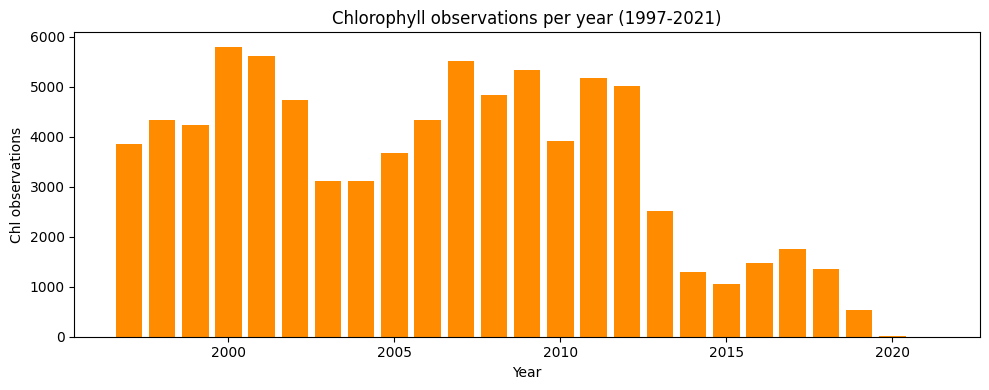

span: 1997-01-02 12:48:00 -> 2021-01-27 00:35:00


In [4]:
year = chla['date_time'].dt.year
per_year = year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(per_year.index, per_year.values, color='darkorange')
ax.set_xlabel('Year'); ax.set_ylabel('Chl observations')
ax.set_title('Chlorophyll observations per year (1997-2021)')
plt.tight_layout()
plt.show()
print('span:', chla['date_time'].min(), '->', chla['date_time'].max())

## How much do the measurement types co-occur?

Every dataset shares the global `ID`, so we can ask how many observations
have *both* chlorophyll and Rrs, chlorophyll and IOPs, etc.

In [5]:
ids = {k: set(v.index) for k, v in frames.items()}
pairs = [('chla', 'rrs'), ('chla', 'iop'), ('rrs', 'iop'),
         ('chla', 'rrs_sat2'), ('rrs', 'rrs_sat2')]
for a, b in pairs:
    print(f'{a:9s} & {b:9s}: {len(ids[a] & ids[b]):,} shared IDs')

chla      & rrs      : 3,840 shared IDs
chla      & iop      : 5,907 shared IDs
rrs       & iop      : 3,408 shared IDs
chla      & rrs_sat2 : 3,840 shared IDs
rrs       & rrs_sat2 : 68,641 shared IDs


## Findings — coverage

* **Sizes.** Chlorophyll is the largest table (~82.5k observations),
  followed by Rrs (~68.6k). The IOP / Kd / TSM tables are an order of
  magnitude smaller (~7.4k) — spectral IOPs are the rarest measurements in
  the compilation.
* **Space.** Coverage is global (lat -78 to +82, full longitude range) but
  strongly clustered on repeat tracks and time-series sites rather than
  evenly distributed.
* **Time.** The record spans 1997-2021 with the bulk of observations in the
  2000s-2010s; the tail years (2020-2021) are sparse.
* **Co-occurrence is partial.** Because not every station measured every
  quantity, the cross-dataset overlaps are modest — e.g. only a few
  thousand IDs carry both chlorophyll and Rrs, and fewer still carry IOPs.
  Analyses that need matched variables must work on these intersections.